In [1]:
import pandas as pd
# Librerías para datos y gráficos
import numpy as np          # Para trabajar con arreglos numéricos
import pandas as pd         # Para manejar tablas de datos (DataFrames)
import matplotlib.pyplot as plt  # Para hacer gráficos
import seaborn as sns

from sklearn.feature_selection import chi2

# Herramientas de machine learning (scikit-learn)
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve, auc                       # Medir calidad de los modelos
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier  # Modelos de árboles

# Para análisis de supervivencia
from lifelines import KaplanMeierFitter                                       # Para crear curvas de supervivencia
from lifelines.statistics import logrank_test                                 # Prueba para comparar curvas
from sksurv.ensemble import RandomSurvivalForest                              # Modelo de bosque para supervivencia
from sksurv.util import Surv                                                   # Formato de datos para supervivencia
from sksurv.metrics import concordance_index_censored                        # Medida para evaluar modelos de supervivencia

# Para balancear datos y generar muestras nuevas
from imblearn.over_sampling import SMOTE                                   # Para balancear datos desbalanceados

# Para usar XGBoost, un modelo potente basado en árboles
import xgboost as xgb     
from xgboost import XGBClassifier     

from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

In [2]:
top25_genes = [
    "CD74",
    "HLA-DPB1",
    "HLA-DRB1",
    "HLA-DMA",
    "HLA-DMB",
    "HLA-DRA",
    "HLA-DPA1",
    "HLA-DOA",
    "HLA-E",
    "HLA-DQA1",
    "PTPRC",
    "LYN",
    "IL10",
    "CD3E",
    "FCGR3A",
    "LCK",
    "CASP1",
    "CD2",
    "B2M",
    "LCP2",
    "SERPING1",
    "CD4",
    "FCER1G",
    "C1QB",
    "C1QC"
]

In [18]:
top25_genes = [
    'CD74', 'HLA-DPB1', 'HLA-DRB1', 'HLA-DMA', 'HLA-DMB', 'HLA-DRA', 'HLA-DPA1', 'HLA-DOA', 'HLA-E', 'HLA-DQA1', 'PTPRC', 'LYN', 'IL10', 'CD3E', 'FCGR3A', 'LCK', 'CASP1', 'CD2', 'B2M', 'LCP2', 'SERPING1', 'CD4', 'FCER1G', 'C1QB', 'C1QC', 'RUNX1', 'HLA-C', 'SYK', 'TIMP1', 'CD44', 'MMP14', 'IL7R', 'COL1A2', 'ISG15', 'IFI44L', 'RSAD2', 'MAOB', 'CASP4', 'CCR5', 'CASP8', 'CTSS', 'CCL5', 'DAPP1', 'HLA-B', 'ITGB2', 'ITGA5', 'PLCG2', 'TYROBP', 'ALOX5', 'LSP1', 'GZMA', 'HLA-DQB1', 'CCR2', 'CYBA', 'NCF1', 'CLEC7A', 'PTGS1', 'RIPK3', 'IL2RB', 'PYGL', 'CD53', 'RUNX3', 'GZMK', 'LAPTM5', 'SPI1', 'ICAM1', 'CD3D', 'CD86', 'HAVCR2', 'ALPK1', 'PTPN22', 'TIFA', 'CXCR3', 'PTPN6', 'CCR1', 'C1S', 'C2', 'HCK', 'VAV1', 'ITGB3', 'PIK3R5', 'HLA-DQA2', 'RNASE2', 'BTK', 'ITGB7', 'LILRB2', 'ANG', 'HCST', 'FCGR2B', 'PIK3R6', 'ITK', 'TLR7', 'PRF1', 'GZMH', 'TLR3', 'IFIH1', 'HERC5', 'COL1A1', 'CD80', 'CD163', 'SERPINH1', 'JAK3', 'CCL2', 'LGALS9C', 'PDCD1', 'LUM', 'TNFRSF11B', 'TNFSF10', 'XAF1', 'COL6A2', 'IFI44', 'ZBP1', 'PHEX', 'ENPP1', 'IRF7', 'SERPINE1', 'GZMB', 'GNLY', 'CXCR2', 'F3', 'CXCR4', 'VCAM1', 'IL6', 'EGR1', 'MMP9', 'FCAR', 'PIGR', 'ALDH3A1', 'AOX1', 'EGR2', 'IBSP', 'CEP55', 'KIF2C', 'HOXD11', 'HOXD10', 'PLBD1', 'SP100', 'CIITA', 'ADPRH', 'KYNU', 'SERPINA1', 'SQRDL', 'MSR1', 'S100A4', 'RAC2', 'FAM129A', 'S100A11', 'GPR65', 'CLIC1', 'PTGER4', 'IL2RG', 'GBP5', 'TRIM38', 'FGL2', 'CTSC', 'APOBEC3G', 'FCGR2A', 'IFI30', 'DENND2D', 'ARHGAP15', 'LTBR', 'TNFAIP8', 'CECR1', 'PLSCR1', 'MSN', 'FCGR2C', 'ELF4', 'ITGAL', 'CD7', 'MYOF', 'ARHGAP25', 'SP140L'
]

In [14]:
path_rppa = '../data/Human__TCGA_LGG__MDA__RPPA__MDA_RPPA__01_28_2016__BI__Gene__Firehose_RPPA.cct.txt'
path_mutation = '../data/Human__TCGA_LGG__WUSM__Mutation__GAIIx__01_28_2016__BI__Gene__Firehose_MutSig2CV.cbt.txt'

path_scna_gen = '../data/Human__TCGA_LGG__BI__SCNA__SNP_6.0__01_28_2016__BI__Gene__Firehose_GISTIC2.cct'

rppa = pd.read_csv(path_rppa, sep='\t', index_col=0)
muta = pd.read_csv(path_mutation, sep='\t', index_col=0)
scna_gen = pd.read_csv(path_scna_gen, sep='\t', index_col=0)

print(f"Dimensión datos rppa: {rppa.shape}")  # espera genes x muestras
print(f"Dimensión datos mutaciones: {muta.shape}")
print(f"Dimensión datos scna: {scna_gen.shape}")

Dimensión datos rppa: (148, 429)
Dimensión datos mutaciones: (889, 513)
Dimensión datos scna: (24776, 513)


In [16]:
rppa = rppa.loc[rppa.index.isin(top25_genes)]
scna_gen = scna_gen.loc[scna_gen.index.isin(top25_genes)]
muta = muta.loc[muta.index.isin(top25_genes)]

print(f"Dimensión datos rppa: {rppa.shape}")  # espera genes x muestras
print(f"Dimensión datos mutaciones: {muta.shape}")
print(f"Dimensión datos scna: {scna_gen.shape}")

print(scna_gen.index.tolist())

Dimensión datos rppa: (1, 429)
Dimensión datos mutaciones: (1, 513)
Dimensión datos scna: (16, 513)
['C1QC', 'C1QB', 'LCK', 'CD2', 'FCER1G', 'FCGR3A', 'PTPRC', 'IL10', 'CD74', 'LCP2', 'LYN', 'SERPING1', 'CASP1', 'CD3E', 'CD4', 'B2M']


In [17]:
scna_gen = scna_gen.T 
scna_gen.head()

attrib_name,C1QC,C1QB,LCK,CD2,FCER1G,FCGR3A,PTPRC,IL10,CD74,LCP2,LYN,SERPING1,CASP1,CD3E,CD4,B2M
TCGA.CS.4938,0.004,0.004,0.004,0.003,0.003,0.003,0.003,0.003,-0.002,-0.002,-0.003,-0.001,-0.001,-0.001,0.067,0.007
TCGA.CS.4941,0.459,0.459,0.459,0.447,0.447,0.447,0.444,0.444,0.003,0.003,-0.015,-0.018,-0.014,-0.014,0.004,-0.027
TCGA.CS.4942,0.002,0.002,0.002,0.002,0.002,0.002,0.002,0.002,-0.019,-0.019,0.000,0.001,0.004,0.004,0.017,0.004
TCGA.CS.4943,-0.043,-0.043,-0.043,-0.043,-0.043,-0.043,-0.043,-0.043,0.005,0.005,-0.007,0.016,0.001,0.001,1.628,0.056
TCGA.CS.4944,-0.009,-0.009,-0.009,-0.691,0.000,0.000,0.000,0.000,0.008,0.008,-0.002,-0.005,0.004,0.004,0.005,-0.011


In [18]:
data_cox = pd.read_csv('../data/data_cox_with_survival3yr_ht.csv', index_col=0)
data_cox.head()


,CD74,HLA-DPB1,HLA-DRB1,HLA-DMA,HLA-DMB,HLA-DRA,HLA-DPA1,HLA-DOA,HLA-E,HLA-DQA1,...,survival_3yr,histological_type_astrocytoma,histological_type_oligoastrocytoma,histological_type_oligodendroglioma,gender_female,gender_male,radiation_therapy_no,radiation_therapy_yes,Tumor_purity,years_to_birth
TCGA.CS.4938,12.5668,8.6102,8.7590,8.5993,8.9834,10.7880,8.8908,6.8782,12.2597,6.8204,...,1,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.9027,-0.925152
TCGA.CS.4941,15.4927,11.9222,12.3668,10.5364,10.8081,13.9021,12.5162,10.0694,13.9244,10.2799,...,0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.7466,1.815359
TCGA.CS.4942,15.3739,11.4483,12.7477,10.5580,10.8706,13.7942,11.9650,10.3466,13.7275,10.4735,...,1,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.7702,0.064477
TCGA.CS.4943,13.2865,10.4928,9.8587,9.0924,9.5139,11.8657,10.5019,8.5010,11.6388,8.4154,...,1,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.9178,-0.468400
TCGA.CS.4944,14.4549,11.6700,11.6364,10.3967,9.8603,13.2601,11.5003,9.0541,12.5336,9.8875,...,1,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.8886,0.521229


In [19]:
# Renombrar columnas de SCNA para indicar origen "_scna"
scna_renamed = scna_gen.add_suffix('_scna')

# Renombrar columnas de expresión para indicar origen "_expression"
cox_renamed = data_cox.add_suffix('_expression')

# Mantener la columna survival_3yr sin sufijo
survival_col = data_cox['survival_3yr']

# Encontrar genes comunes
genes_cox = set([col.replace('_expression', '') for col in cox_renamed.columns])
genes_scna = set([col.replace('_scna', '') for col in scna_renamed.columns])
common_genes = genes_cox.intersection(genes_scna)

# Filtrar matrices por genes comunes
cols_cox_common = [gene + '_expression' for gene in common_genes]
cols_scna_common = [gene + '_scna' for gene in common_genes]

cox_filtered = cox_renamed[cols_cox_common]
scna_filtered = scna_renamed[cols_scna_common]

# Unir por índice de muestra
merged_data = pd.merge(cox_filtered, scna_filtered, left_index=True, right_index=True, how='inner')

# Añadir la columna survival_3yr
merged_data = merged_data.join(survival_col, how='inner')

# Ordenar columnas: expresión y SCNA lado a lado por gen
ordered_cols = []
for gene in sorted(common_genes):
    ordered_cols.append(gene + '_expression')
    ordered_cols.append(gene + '_scna')
ordered_cols.append('survival_3yr')

merged_data = merged_data[ordered_cols]

# Vista final
print(merged_data.head())



              B2M_expression  B2M_scna  C1QB_expression  C1QB_scna  \
TCGA.CS.4938         14.0208     0.007          11.3329      0.004   
TCGA.CS.4941         15.7253    -0.027          12.5445      0.459   
TCGA.CS.4942         15.6693     0.004          13.3568      0.002   
TCGA.CS.4943         13.6961     0.056          11.8849     -0.043   
TCGA.CS.4944         14.4556    -0.011          11.4629     -0.009   

              C1QC_expression  C1QC_scna  CASP1_expression  CASP1_scna  \
TCGA.CS.4938          11.2728      0.004            7.3958      -0.001   
TCGA.CS.4941          12.4334      0.459            8.4219      -0.014   
TCGA.CS.4942          13.2014      0.002            8.5825       0.004   
TCGA.CS.4943          11.9314     -0.043            7.1080       0.001   
TCGA.CS.4944          11.5642     -0.009            7.0236       0.004   

              CD2_expression  CD2_scna  ...  LCK_scna  LCP2_expression  \
TCGA.CS.4938          1.6312     0.003  ...     0.004       

In [20]:
data_cox.head()

,CD74,HLA-DPB1,HLA-DRB1,HLA-DMA,HLA-DMB,HLA-DRA,HLA-DPA1,HLA-DOA,HLA-E,HLA-DQA1,...,survival_3yr,histological_type_astrocytoma,histological_type_oligoastrocytoma,histological_type_oligodendroglioma,gender_female,gender_male,radiation_therapy_no,radiation_therapy_yes,Tumor_purity,years_to_birth
TCGA.CS.4938,12.5668,8.6102,8.7590,8.5993,8.9834,10.7880,8.8908,6.8782,12.2597,6.8204,...,1,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.9027,-0.925152
TCGA.CS.4941,15.4927,11.9222,12.3668,10.5364,10.8081,13.9021,12.5162,10.0694,13.9244,10.2799,...,0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.7466,1.815359
TCGA.CS.4942,15.3739,11.4483,12.7477,10.5580,10.8706,13.7942,11.9650,10.3466,13.7275,10.4735,...,1,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.7702,0.064477
TCGA.CS.4943,13.2865,10.4928,9.8587,9.0924,9.5139,11.8657,10.5019,8.5010,11.6388,8.4154,...,1,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.9178,-0.468400
TCGA.CS.4944,14.4549,11.6700,11.6364,10.3967,9.8603,13.2601,11.5003,9.0541,12.5336,9.8875,...,1,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.8886,0.521229


In [21]:
merged_data.head()

,B2M_expression,B2M_scna,C1QB_expression,C1QB_scna,C1QC_expression,C1QC_scna,CASP1_expression,CASP1_scna,CD2_expression,CD2_scna,...,LCK_scna,LCP2_expression,LCP2_scna,LYN_expression,LYN_scna,PTPRC_expression,PTPRC_scna,SERPING1_expression,SERPING1_scna,survival_3yr
TCGA.CS.4938,14.0208,0.007,11.3329,0.004,11.2728,0.004,7.3958,-0.001,1.6312,0.003,...,0.004,7.6154,-0.002,8.9073,-0.003,7.9303,0.003,8.2515,-0.001,1
TCGA.CS.4941,15.7253,-0.027,12.5445,0.459,12.4334,0.459,8.4219,-0.014,6.5359,0.447,...,0.459,9.0451,0.003,10.5100,-0.015,9.5845,0.444,11.8442,-0.018,0
TCGA.CS.4942,15.6693,0.004,13.3568,0.002,13.2014,0.002,8.5825,0.004,4.3971,0.002,...,0.002,9.2850,-0.019,10.4678,0.000,10.3002,0.002,9.8687,0.001,1
TCGA.CS.4943,13.6961,0.056,11.8849,-0.043,11.9314,-0.043,7.1080,0.001,2.3893,-0.043,...,-0.043,7.9089,0.005,8.7019,-0.007,8.2115,-0.043,7.9684,0.016,1
TCGA.CS.4944,14.4556,-0.011,11.4629,-0.009,11.5642,-0.009,7.0236,0.004,3.9186,-0.691,...,-0.009,6.9549,0.008,8.1417,-0.002,7.2412,0.000,10.4694,-0.005,1


In [23]:
# Lista de prefijos de las variables categóricas originales
categorical_prefixes = ['histological_type', 'gender', 'radiation_therapy']

# Identificar todas las columnas codificadas (one-hot) en data_cox_final
encoded_cols = [
    col for col in data_cox.columns
    if any(col.startswith(prefix) for prefix in categorical_prefixes)
]

# Añadir las columnas numéricas procesadas
numeric_cols_processed = ['Tumor_purity', 'years_to_birth']

# Todas las columnas a unir
cols_to_add = encoded_cols + numeric_cols_processed

# Verificar que todas existan en data_cox_final
missing_cols = [col for col in cols_to_add if col not in data_cox.columns]
if missing_cols:
    raise ValueError(f"Las siguientes columnas no se encuentran en data_cox_final: {missing_cols}")

# Unir a merged_data por índice (solo filas comunes)
merged_data = merged_data.join(data_cox[cols_to_add], how='inner')

print(f"✅ Se añadieron {len(cols_to_add)} columnas a merged_data.")
print(f"   Nuevas columnas: {cols_to_add}")

✅ Se añadieron 9 columnas a merged_data.
   Nuevas columnas: ['histological_type_astrocytoma', 'histological_type_oligoastrocytoma', 'histological_type_oligodendroglioma', 'gender_female', 'gender_male', 'radiation_therapy_no', 'radiation_therapy_yes', 'Tumor_purity', 'years_to_birth']


In [24]:
merged_data.head()

,B2M_expression,B2M_scna,C1QB_expression,C1QB_scna,C1QC_expression,C1QC_scna,CASP1_expression,CASP1_scna,CD2_expression,CD2_scna,...,survival_3yr,histological_type_astrocytoma,histological_type_oligoastrocytoma,histological_type_oligodendroglioma,gender_female,gender_male,radiation_therapy_no,radiation_therapy_yes,Tumor_purity,years_to_birth
TCGA.CS.4938,14.0208,0.007,11.3329,0.004,11.2728,0.004,7.3958,-0.001,1.6312,0.003,...,1,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.9027,-0.925152
TCGA.CS.4941,15.7253,-0.027,12.5445,0.459,12.4334,0.459,8.4219,-0.014,6.5359,0.447,...,0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.7466,1.815359
TCGA.CS.4942,15.6693,0.004,13.3568,0.002,13.2014,0.002,8.5825,0.004,4.3971,0.002,...,1,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.7702,0.064477
TCGA.CS.4943,13.6961,0.056,11.8849,-0.043,11.9314,-0.043,7.1080,0.001,2.3893,-0.043,...,1,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.9178,-0.468400
TCGA.CS.4944,14.4556,-0.011,11.4629,-0.009,11.5642,-0.009,7.0236,0.004,3.9186,-0.691,...,1,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.8886,0.521229


In [25]:
# Mover la columna 'survival_3yr' al final del DataFrame
cols = [col for col in merged_data.columns if col != 'survival_3yr'] + ['survival_3yr']
merged_data = merged_data[cols]


In [26]:
merged_data.head()

,B2M_expression,B2M_scna,C1QB_expression,C1QB_scna,C1QC_expression,C1QC_scna,CASP1_expression,CASP1_scna,CD2_expression,CD2_scna,...,histological_type_astrocytoma,histological_type_oligoastrocytoma,histological_type_oligodendroglioma,gender_female,gender_male,radiation_therapy_no,radiation_therapy_yes,Tumor_purity,years_to_birth,survival_3yr
TCGA.CS.4938,14.0208,0.007,11.3329,0.004,11.2728,0.004,7.3958,-0.001,1.6312,0.003,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.9027,-0.925152,1
TCGA.CS.4941,15.7253,-0.027,12.5445,0.459,12.4334,0.459,8.4219,-0.014,6.5359,0.447,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.7466,1.815359,0
TCGA.CS.4942,15.6693,0.004,13.3568,0.002,13.2014,0.002,8.5825,0.004,4.3971,0.002,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.7702,0.064477,1
TCGA.CS.4943,13.6961,0.056,11.8849,-0.043,11.9314,-0.043,7.1080,0.001,2.3893,-0.043,...,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.9178,-0.468400,1
TCGA.CS.4944,14.4556,-0.011,11.4629,-0.009,11.5642,-0.009,7.0236,0.004,3.9186,-0.691,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.8886,0.521229,1


In [27]:
merged_data.to_csv('data.csv', index=False)

## EDA

In [28]:
# General info
print("Resumen de tipos de datos y valores no nulos:")
print(merged_data.info())

print("\nDescriptivo general:")
print(merged_data.describe(include='all'))

print("\nPrimeras filas del DataFrame:")
print(merged_data.head())

print("\nConteo de valores para la variable objetivo:")
print(merged_data['survival_3yr'].value_counts())

Resumen de tipos de datos y valores no nulos:
<class 'pandas.core.frame.DataFrame'>
Index: 461 entries, TCGA.CS.4938 to TCGA.WY.A85E
Data columns (total 42 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   B2M_expression                       461 non-null    float64
 1   B2M_scna                             461 non-null    float64
 2   C1QB_expression                      461 non-null    float64
 3   C1QB_scna                            461 non-null    float64
 4   C1QC_expression                      461 non-null    float64
 5   C1QC_scna                            461 non-null    float64
 6   CASP1_expression                     461 non-null    float64
 7   CASP1_scna                           461 non-null    float64
 8   CD2_expression                       461 non-null    float64
 9   CD2_scna                             461 non-null    float64
 10  CD3E_expression                      

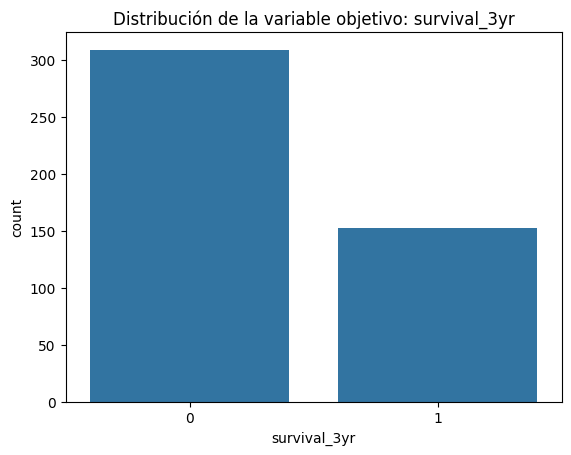

In [29]:
# Visualización de la variable objetivo
sns.countplot(x='survival_3yr', data=merged_data)
plt.title('Distribución de la variable objetivo: survival_3yr')
plt.show()

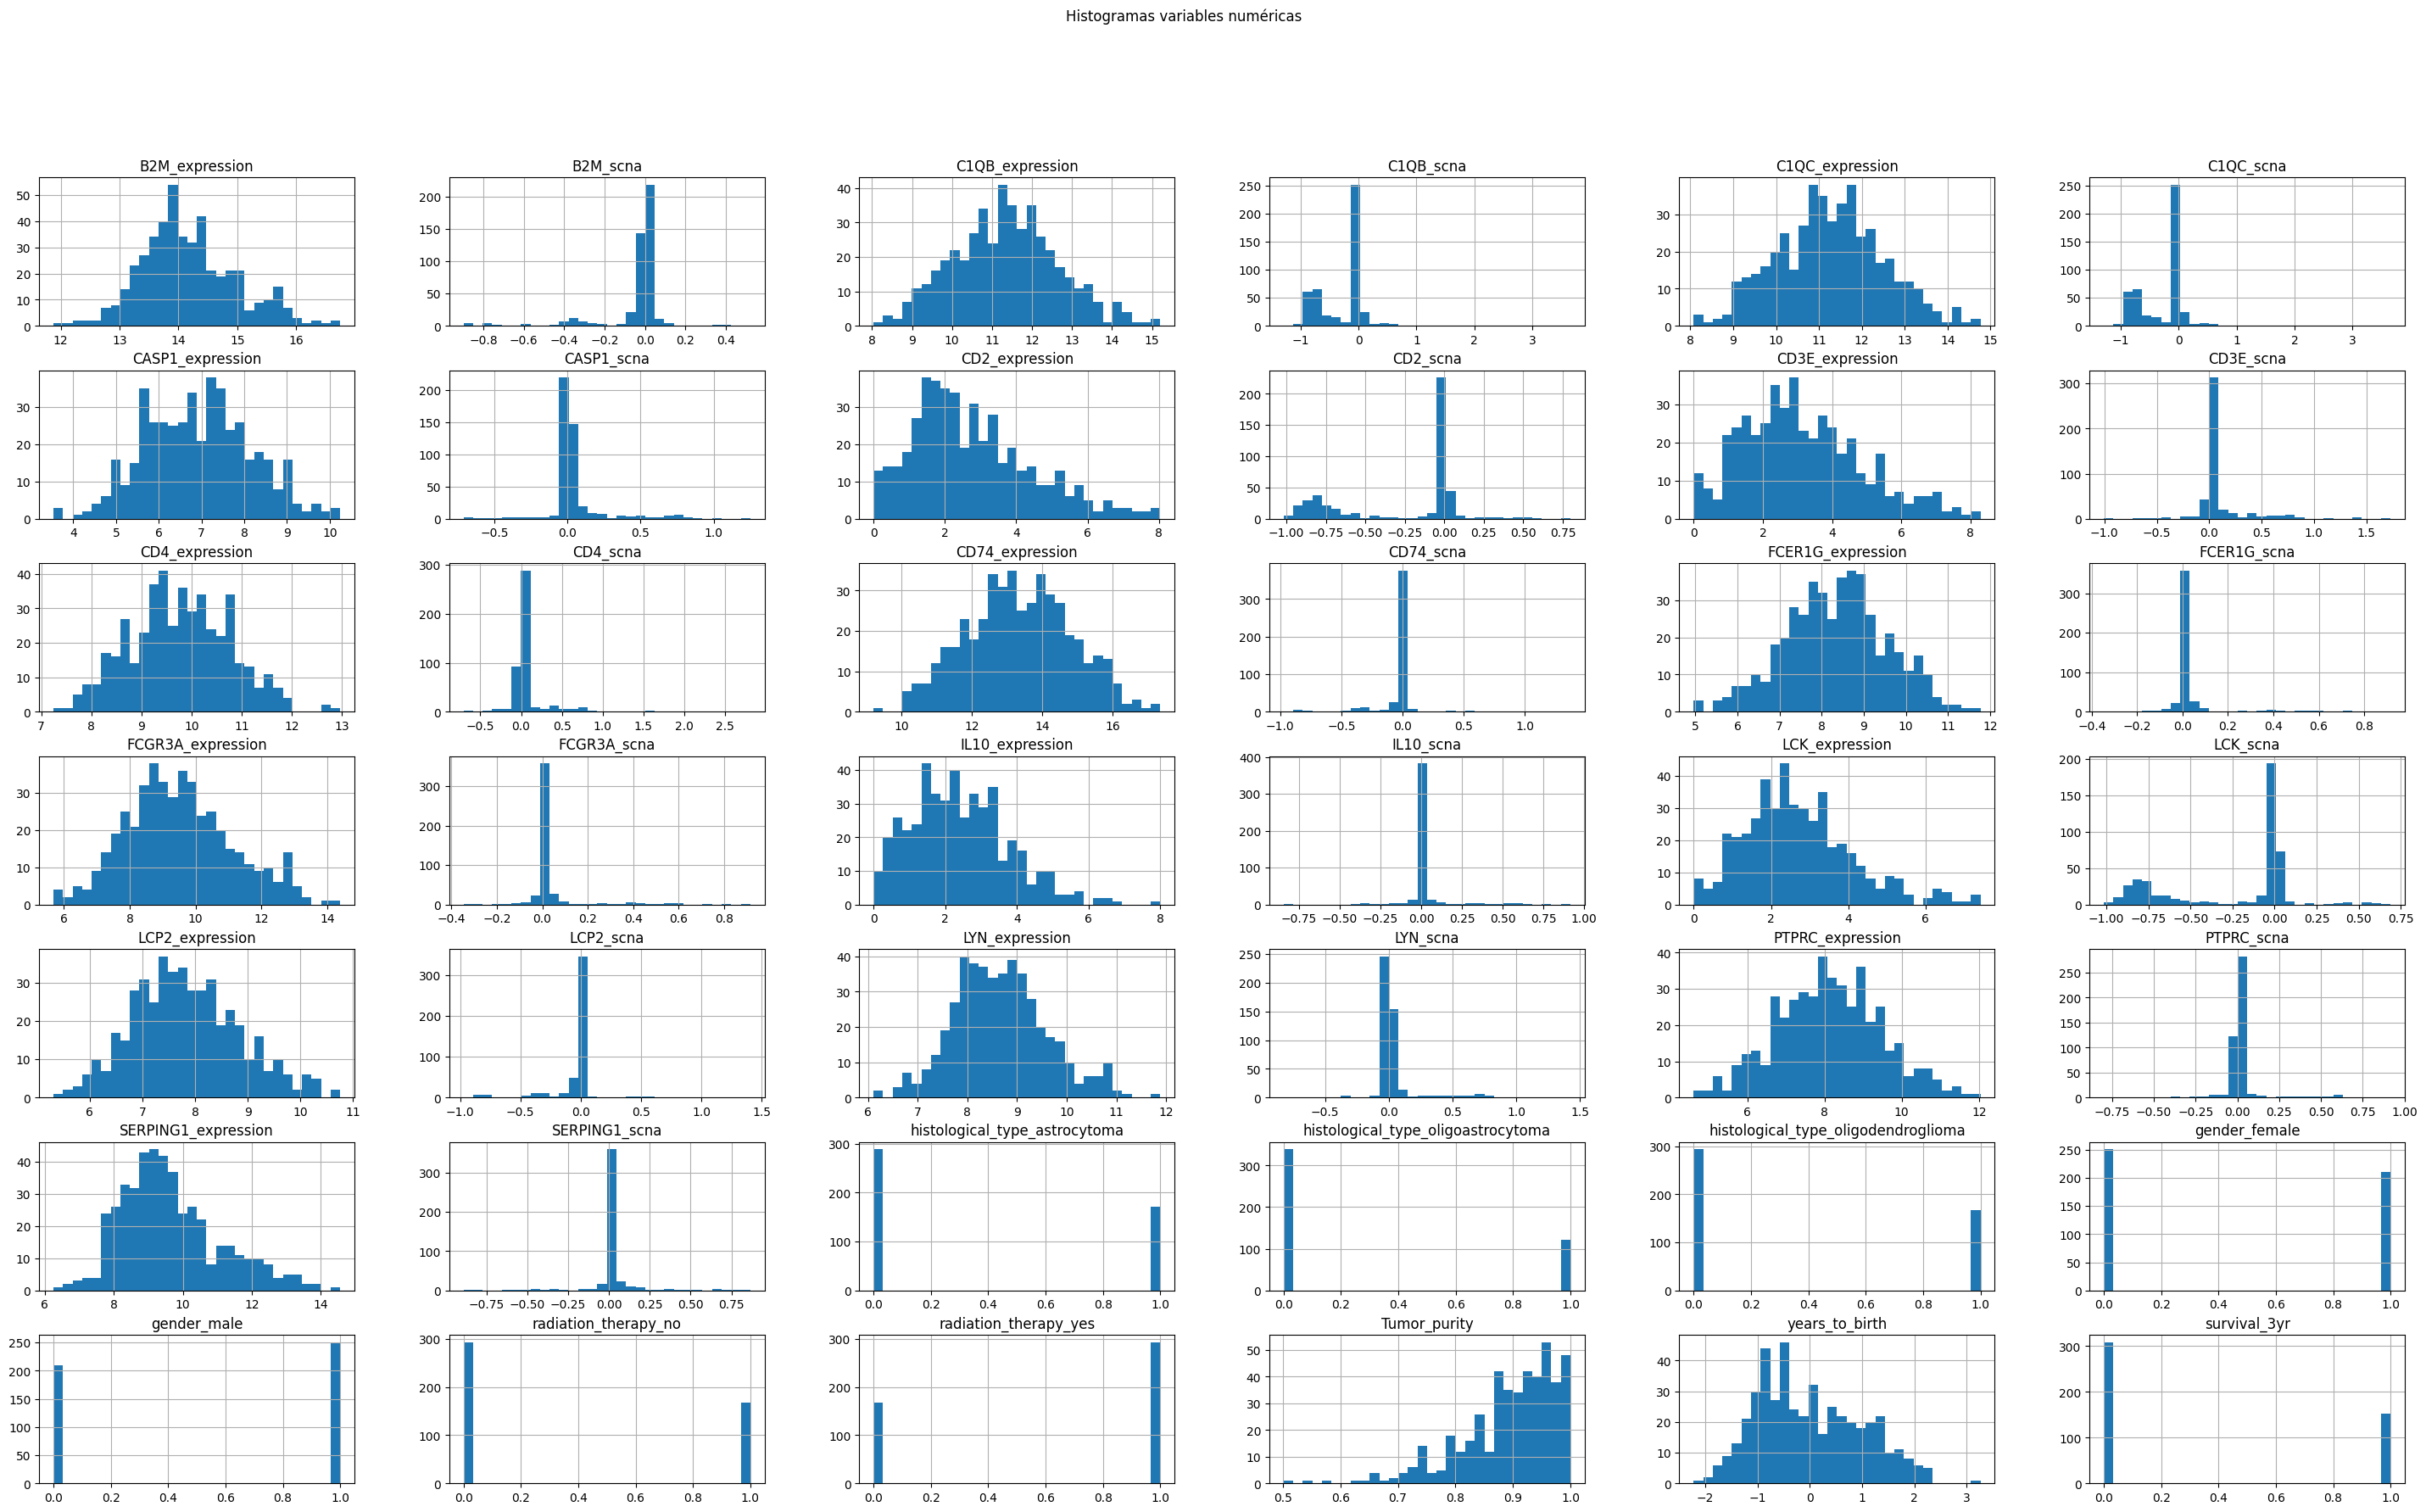

In [35]:
merged_data.hist(bins=30, figsize=(36, 20))
plt.suptitle('Histogramas variables numéricas')
plt.show()

In [56]:
# Boxplots para variables numéricas vs target
num_cols = merged_data.select_dtypes(include=['float64', 'int']).columns
'''for col in num_cols:
    if col != 'survival_3yr':
        sns.boxplot(x='survival_3yr', y=col, data=merged_data)
        plt.title(f'Boxplot de {col} por survival_3yr')
        plt.show()'''

"for col in num_cols:\n    if col != 'survival_3yr':\n        sns.boxplot(x='survival_3yr', y=col, data=merged_data)\n        plt.title(f'Boxplot de {col} por survival_3yr')\n        plt.show()"

In [57]:
# Correlación de variables numéricas
'''plt.figure(figsize=(20, 18))
sns.heatmap(merged_data[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Matriz de correlación')
plt.show()'''

"plt.figure(figsize=(20, 18))\nsns.heatmap(merged_data[num_cols].corr(), annot=True, cmap='coolwarm')\nplt.title('Matriz de correlación')\nplt.show()"

In [58]:
# Filtrar columnas que empiezan con 'histological_type'
'''hist_cols = [col for col in merged_data.columns if col.startswith('histological_type')]

for col in hist_cols:
    print(f"\nValor de conteos en {col}:")
    print(merged_data[col].value_counts())
    sns.countplot(x=col, data=merged_data, hue='survival_3yr')
    plt.title(f'{col} por survival_3yr')
    plt.xticks(rotation=45)
    plt.show()'''


'hist_cols = [col for col in merged_data.columns if col.startswith(\'histological_type\')]\n\nfor col in hist_cols:\n    print(f"\nValor de conteos en {col}:")\n    print(merged_data[col].value_counts())\n    sns.countplot(x=col, data=merged_data, hue=\'survival_3yr\')\n    plt.title(f\'{col} por survival_3yr\')\n    plt.xticks(rotation=45)\n    plt.show()'

In [59]:
#Correlación de Pearson para variables numéricas
'''num_cols = merged_data.select_dtypes(include=['float64', 'int']).columns
if 'survival_3yr' in num_cols:
    num_cols = num_cols.drop('survival_3yr')  # Evita autoco-correlación

correlations = merged_data[num_cols].corrwith(merged_data['survival_3yr']).abs().sort_values(ascending=False)
print("Correlaciones con survival_3yr:")
print(correlations)'''

'num_cols = merged_data.select_dtypes(include=[\'float64\', \'int\']).columns\nif \'survival_3yr\' in num_cols:\n    num_cols = num_cols.drop(\'survival_3yr\')  # Evita autoco-correlación\n\ncorrelations = merged_data[num_cols].corrwith(merged_data[\'survival_3yr\']).abs().sort_values(ascending=False)\nprint("Correlaciones con survival_3yr:")\nprint(correlations)'

In [60]:
#Importancia según RandomForest (considerando todas las variables)
'''X = merged_data.drop('survival_3yr', axis=1)
y = merged_data['survival_3yr']

# Ya no aplicamos get_dummies porque las columnas histological_type ya están como one-hot
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

importancias = pd.Series(rf.feature_importances_, index=X.columns)
importancias = importancias.sort_values(ascending=False)
print("Importancia según RandomForest:")
print(importancias)'''

'X = merged_data.drop(\'survival_3yr\', axis=1)\ny = merged_data[\'survival_3yr\']\n\n# Ya no aplicamos get_dummies porque las columnas histological_type ya están como one-hot\nrf = RandomForestClassifier(n_estimators=100, random_state=42)\nrf.fit(X, y)\n\nimportancias = pd.Series(rf.feature_importances_, index=X.columns)\nimportancias = importancias.sort_values(ascending=False)\nprint("Importancia según RandomForest:")\nprint(importancias)'

In [61]:
# Visualización
'''importancias.head(20).plot(kind='barh', figsize=(8, 6))
plt.title('Top 20 características más importantes (RandomForest)')
plt.gca().invert_yaxis()
plt.show()'''

"importancias.head(20).plot(kind='barh', figsize=(8, 6))\nplt.title('Top 20 características más importantes (RandomForest)')\nplt.gca().invert_yaxis()\nplt.show()"

In [62]:
#Chi-cuadrado para variables categóricas (one-hot de histological_type)

'''if hist_cols:
    chi_scores = chi2(merged_data[hist_cols], y)
    chi2_df = pd.DataFrame({'Feature': hist_cols, 'Chi2 Score': chi_scores[0]})
    chi2_df = chi2_df.sort_values('Chi2 Score', ascending=False)
    print("Chi-cuadrado para variables histological_type:")
    print(chi2_df.head(10))
else:
    print("No se encontraron columnas que empiecen con 'histological_type' para análisis chi-cuadrado.")'''

'if hist_cols:\n    chi_scores = chi2(merged_data[hist_cols], y)\n    chi2_df = pd.DataFrame({\'Feature\': hist_cols, \'Chi2 Score\': chi_scores[0]})\n    chi2_df = chi2_df.sort_values(\'Chi2 Score\', ascending=False)\n    print("Chi-cuadrado para variables histological_type:")\n    print(chi2_df.head(10))\nelse:\n    print("No se encontraron columnas que empiecen con \'histological_type\' para análisis chi-cuadrado.")'

## Modelos

In [14]:
# Función para evaluar modelo y obtener AUC
def evaluar_modelo(modelo, X, y, cv):
    auc_scores = []
    for train_idx, test_idx in cv.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        modelo.fit(X_train, y_train)
        y_proba = modelo.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
        auc_scores.append(auc)

    return auc_scores, y_test, y_proba

In [17]:
from imblearn.over_sampling import RandomOverSampler, ADASYN, SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN, SMOTETomek


# Ejemplos
ros = RandomOverSampler(random_state=42)
adasyn = ADASYN(random_state=42)
smoteenn = SMOTEENN(random_state=42)
smotetomek = SMOTETomek(random_state=42)
rus = RandomUnderSampler(random_state=42)

In [18]:
X = merged_data.drop('survival_3yr', axis=1)
y = merged_data['survival_3yr']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

smote = SMOTE(random_state=42)
# validacion cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

X_train_smote, y_train_smote = ros.fit_resample(X_train, y_train)
#X_train_smote, y_train_smote = adasyn.fit_resample(X_train, y_train)
#X_train_smote, y_train_smote = smoteenn.fit_resample(X_train, y_train)
#X_train_smote, y_train_smote = smotetomek.fit_resample(X_train, y_train)
#X_train_smote, y_train_smote = rus.fit_resample(X_train, y_train)
# sin smote
#X_train_smote, y_train_smote = X_train, y_train

In [20]:
from sklearn.svm import OneClassSVM
from sklearn.metrics import roc_auc_score
from itertools import product
import numpy as np

# OneClassSVM es para detección de anomalías, no clasificación binaria
# Asume que la clase mayoritaria es "normal" y la minoritaria es "anomalía"

param_grid = {
    'nu': [0.001, 0.01, 0.05, 0.1, 0.2],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1]
}

best_auc = -1
best_params = None
best_model = None

# Para OneClassSVM, solo entrenas con la clase "normal"
# Asumiendo que la clase 0 es la normal y 1 es anomalía
X_train_normal = X_train_smote[y_train_smote == 0]

for nu, gamma in product(param_grid['nu'], param_grid['gamma']):
    try:
        model = OneClassSVM(kernel='rbf', nu=nu, gamma=gamma)
        model.fit(X_train_normal)  # Solo X, sin y
        
        # Puntuaciones de decisión (menor = más anómalo)
        decision_scores = model.decision_function(X_test)
        
        # Para AUC, invertimos las scores ya que menor valor = más anómalo
        # y queremos que anomalías (clase 1) tengan mayor probabilidad
        auc_val = roc_auc_score(y_test, -decision_scores)
        
        if auc_val > best_auc:
            best_auc = auc_val
            best_params = {'nu': nu, 'gamma': gamma}
            best_model = model
            
    except Exception as e:
        print(f"Error con nu={nu}, gamma={gamma}: {e}")
        continue

print(f"Mejores hiperparámetros: {best_params}")
print(f"Mejor AUC en test: {best_auc:.4f}")

Mejores hiperparámetros: {'nu': 0.1, 'gamma': 'scale'}
Mejor AUC en test: 0.5672


In [23]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import roc_auc_score, classification_report
from imblearn.over_sampling import RandomOverSampler  # ¡ROS en lugar de SMOTE!
from imblearn.pipeline import Pipeline
import numpy as np

# Pipeline: escalado → ROS → SVM
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ros', RandomOverSampler(random_state=42)),  # ROS en lugar de SMOTE
    ('svm', SVC(
        kernel='rbf',
        class_weight='balanced',  # ¡Sigue siendo útil incluso con ROS!
        probability=True,
        random_state=42,
        max_iter=10000
    ))
])

# Grilla de hiperparámetros
param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 'auto', 0.001, 0.01, 0.1]
}

best_auc = -1
best_params = None
best_pipeline = None

for C in param_grid['svm__C']:
    for gamma in param_grid['svm__gamma']:
        try:
            pipeline.set_params(svm__C=C, svm__gamma=gamma)
            
            cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
            cv_results = cross_validate(
                pipeline, X_train, y_train,  # Datos originales, sin sobremuestreo previo
                cv=cv,
                scoring='roc_auc',
                n_jobs=-1,
                return_estimator=True
            )
            
            mean_auc = cv_results['test_score'].mean()
            
            if mean_auc > best_auc:
                best_auc = mean_auc
                best_params = {'C': C, 'gamma': gamma}
                best_pipeline = cv_results['estimator'][-1]
                print(f"Mejor CV AUC: {mean_auc:.4f} con C={C}, gamma={gamma}")
                
        except Exception as e:
            print(f"Error con C={C}, gamma={gamma}: {e}")
            continue

# Evaluación final en test
y_pred_proba = best_pipeline.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, y_pred_proba)
y_pred = best_pipeline.predict(X_test)

print(f"\nMejores hiperparámetros: {best_params}")
print(f"CV AUC: {best_auc:.4f}")
print(f"Test AUC: {test_auc:.4f}")
print("\nReporte de clasificación (test):")
print(classification_report(y_test, y_pred, target_names=['Control', 'Caso']))

Mejor CV AUC: 0.6030 con C=0.1, gamma=scale
Mejor CV AUC: 0.6040 con C=0.1, gamma=auto
Mejor CV AUC: 0.6105 con C=0.1, gamma=0.01
Mejor CV AUC: 0.6279 con C=1, gamma=scale

Mejores hiperparámetros: {'C': 1, 'gamma': 'scale'}
CV AUC: 0.6279
Test AUC: 0.5598

Reporte de clasificación (test):
              precision    recall  f1-score   support

     Control       0.68      0.69      0.69        65
        Caso       0.33      0.32      0.33        31

    accuracy                           0.57        96
   macro avg       0.51      0.51      0.51        96
weighted avg       0.57      0.57      0.57        96



## Enfoque en Recall

=== Evaluación de modelos (requiriendo recall ≥ 70% en 'Fallece <3 años') ===

🔹 Evaluando: Regresión Logística
   Umbral óptimo: 0.410
   Recall (detecta muerte <3 años): 80.6%
   Precisión / VPP: 43.9%
   VPN: 84.6%
   F1-score: 0.568
   Reporte de clasificación:
                   precision    recall  f1-score   support

Sobrevive ≥3 años       0.85      0.51      0.63        65
  Fallece <3 años       0.44      0.81      0.57        31

         accuracy                           0.60        96
        macro avg       0.64      0.66      0.60        96
     weighted avg       0.71      0.60      0.61        96



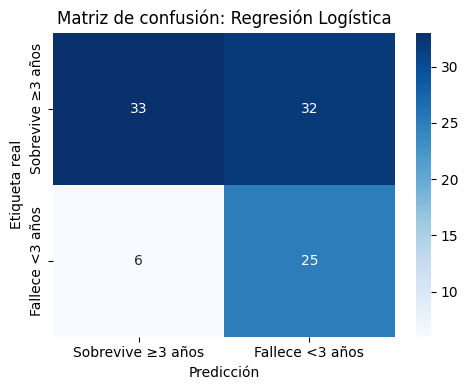

------------------------------------------------------------
🔹 Evaluando: SVM
   Umbral óptimo: 0.303
   Recall (detecta muerte <3 años): 74.2%
   Precisión / VPP: 41.1%
   VPN: 80.0%
   F1-score: 0.529
   Reporte de clasificación:
                   precision    recall  f1-score   support

Sobrevive ≥3 años       0.80      0.49      0.61        65
  Fallece <3 años       0.41      0.74      0.53        31

         accuracy                           0.57        96
        macro avg       0.61      0.62      0.57        96
     weighted avg       0.67      0.57      0.58        96



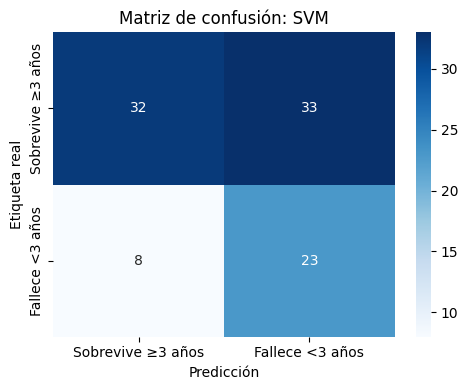

------------------------------------------------------------
🔹 Evaluando: Random Forest
   Umbral óptimo: 0.322
   Recall (detecta muerte <3 años): 87.1%
   Precisión / VPP: 35.5%
   VPN: 80.0%
   F1-score: 0.505
   Reporte de clasificación:
                   precision    recall  f1-score   support

Sobrevive ≥3 años       0.80      0.25      0.38        65
  Fallece <3 años       0.36      0.87      0.50        31

         accuracy                           0.45        96
        macro avg       0.58      0.56      0.44        96
     weighted avg       0.66      0.45      0.42        96



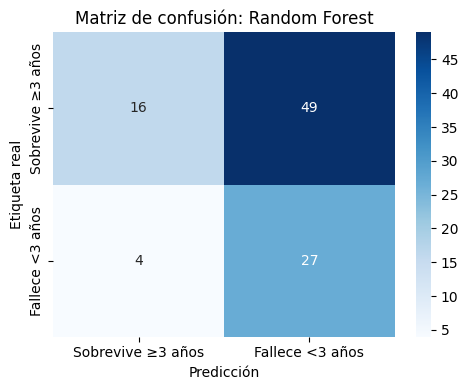

------------------------------------------------------------
🔹 Evaluando: XGBoost


d:\Coding\investigacionIA\entorno\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:21:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


   Umbral óptimo: 0.041
   Recall (detecta muerte <3 años): 71.0%
   Precisión / VPP: 36.7%
   VPN: 75.0%
   F1-score: 0.484
   Reporte de clasificación:
                   precision    recall  f1-score   support

Sobrevive ≥3 años       0.75      0.42      0.53        65
  Fallece <3 años       0.37      0.71      0.48        31

         accuracy                           0.51        96
        macro avg       0.56      0.56      0.51        96
     weighted avg       0.63      0.51      0.52        96



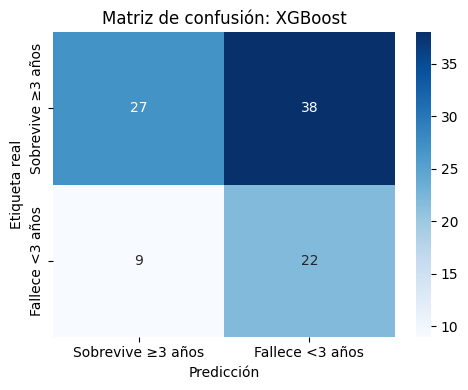

------------------------------------------------------------

=== RESUMEN DE MODELOS (ordenado por F1-score) ===
             Modelo  Umbral  Recall (Sensibilidad)  Precisión (VPP)  F1-score   VPN  AUC-ROC  AUC-PR
Regresión Logística   0.410                  0.806            0.439     0.568 0.846    0.634   0.416
                SVM   0.303                  0.742            0.411     0.529 0.800    0.567   0.360
      Random Forest   0.322                  0.871            0.355     0.505 0.800    0.510   0.342
            XGBoost   0.041                  0.710            0.367     0.484 0.750    0.545   0.364


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    average_precision_score
)
from sklearn.model_selection import train_test_split  # solo si no tienes X_train/X_test definidos

# -------------------------------------------------
# 1. DATOS: Asegúrate de que X_train, X_test, y_train, y_test estén definidos
# Si no los tienes, descomenta las líneas siguientes:
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, 
#                                                     stratify=y, random_state=42)
# -------------------------------------------------

# -------------------------------------------------
# 2. ESCALADO (solo para modelos que lo necesitan)
# -------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -------------------------------------------------
# 3. FUNCIÓN: encontrar umbral con recall mínimo
# -------------------------------------------------
def find_threshold_min_recall(y_true, y_proba, min_recall=0.6):
    """
    Encuentra el umbral que maximiza la precisión,
    sujeto a un recall mínimo exigido.
    """
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    # Añadir punto extremo (umbral = 1.0)
    precision = np.append(precision, 1.0)
    recall = np.append(recall, 0.0)
    thresholds = np.append(thresholds, 1.0)
    
    valid = recall >= min_recall
    if not np.any(valid):
        return None, None, None, None  # No se cumple el requisito
    
    best_idx = np.argmax(precision * valid)
    return thresholds[best_idx], precision[best_idx], recall[best_idx], f1_score_from_pr(precision[best_idx], recall[best_idx])

def f1_score_from_pr(p, r):
    if p + r == 0:
        return 0.0
    return 2 * (p * r) / (p + r)

# -------------------------------------------------
# 4. DEFINIR MODELOS
# -------------------------------------------------
models = {
    "Regresión Logística": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    "SVM": SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42, C=1, gamma='scale'),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', max_depth=5, random_state=42),
    "XGBoost": XGBClassifier(
        scale_pos_weight=len(y_train[y_train == 0]) / len(y_train[y_train == 1]),
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    )
}

# -------------------------------------------------
# 5. EVALUAR MODELOS
# -------------------------------------------------
results = []
min_recall_required = 0.70  # Exigimos al menos 70% de sensibilidad para muerte <3 años

print(f"=== Evaluación de modelos (requiriendo recall ≥ {min_recall_required:.0%} en 'Fallece <3 años') ===\n")

for name, model in models.items():
    print(f"🔹 Evaluando: {name}")
    
    # Ajustar modelo
    if name == "XGBoost":
        model.fit(X_train, y_train)
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        model.fit(X_train_scaled, y_train)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Encontrar umbral
    thresh, prec, rec, f1 = find_threshold_min_recall(y_test, y_proba, min_recall=min_recall_required)
    
    if thresh is None:
        print(f"   ❌ No alcanza recall ≥ {min_recall_required:.0%}\n")
        continue
    
    # Predecir
    y_pred = (y_proba >= thresh).astype(int)
    
    # Métricas adicionales
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    vpp = tp / (tp + fp) if (tp + fp) > 0 else 0  # Valor Predictivo Positivo
    vpn = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor Predictivo Negativo
    auc_roc = roc_auc_score(y_test, y_proba)
    auc_pr = average_precision_score(y_test, y_proba)
    
    results.append({
        "Modelo": name,
        "Umbral": thresh,
        "Recall (Sensibilidad)": rec,
        "Precisión (VPP)": prec,
        "F1-score": f1,
        "VPN": vpn,
        "AUC-ROC": auc_roc,
        "AUC-PR": auc_pr,
        "y_pred": y_pred,
        "y_proba": y_proba
    })
    
    # Mostrar resultados
    print(f"   Umbral óptimo: {thresh:.3f}")
    print(f"   Recall (detecta muerte <3 años): {rec:.1%}")
    print(f"   Precisión / VPP: {prec:.1%}")
    print(f"   VPN: {vpn:.1%}")
    print(f"   F1-score: {f1:.3f}")
    print("   Reporte de clasificación:")
    print(classification_report(y_test, y_pred, target_names=['Sobrevive ≥3 años', 'Fallece <3 años']))
    
    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Sobrevive ≥3 años', 'Fallece <3 años'],
                yticklabels=['Sobrevive ≥3 años', 'Fallece <3 años'])
    plt.title(f'Matriz de confusión: {name}')
    plt.ylabel('Etiqueta real')
    plt.xlabel('Predicción')
    plt.tight_layout()
    plt.savefig(f'matriz_confusion_{name.replace(" ", "_")}.png', dpi=150)
    plt.show()
    print("-" * 60)

# -------------------------------------------------
# 6. RESUMEN FINAL
# -------------------------------------------------
if results:
    df_results = pd.DataFrame([{k: v for k, v in r.items() if k not in ['y_pred', 'y_proba']} for r in results])
    print("\n=== RESUMEN DE MODELOS (ordenado por F1-score) ===")
    print(df_results.sort_values('F1-score', ascending=False).to_string(index=False, float_format='%.3f'))
else:
    print("❌ Ningún modelo alcanzó el recall mínimo requerido.")

## Enfoque AUC

[LightGBM] [Info] Number of positive: 257, number of negative: 257
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006938 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 40393
[LightGBM] [Info] Number of data points in the train set: 514, number of used features: 319
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits w

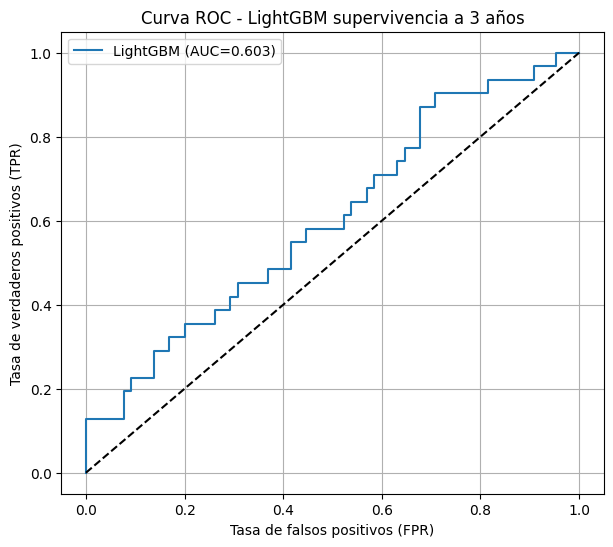

In [67]:
# Entrenamiento
lgbm_clf = LGBMClassifier(random_state=42, colsample_bytree=1.0, learning_rate=0.2, max_depth=7, n_estimators=200, num_leaves=31, subsample=0.8)
lgbm_clf.fit(X_train_smote, y_train_smote)

# Métricas en entrenamiento
y_pred_train = lgbm_clf.predict_proba(X_train)[:,1]
auc_train = roc_auc_score(y_train, y_pred_train)
print(f"AUC ROC entrenamiento: {auc_train:.4f}")

# Métricas en test (original)
y_pred_test = lgbm_clf.predict_proba(X_test)[:,1]
auc_test = roc_auc_score(y_test, y_pred_test)
print(f"AUC ROC test: {auc_test:.4f}")

# Curva ROC para test
fpr, tpr, _ = roc_curve(y_test, y_pred_test)
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f'LightGBM (AUC={auc_test:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curva ROC - LightGBM supervivencia a 3 años')
plt.legend()
plt.grid(True)
plt.show()

AUC ROC entrenamiento (SMOTE): 1.0000
AUC ROC test: 0.6119


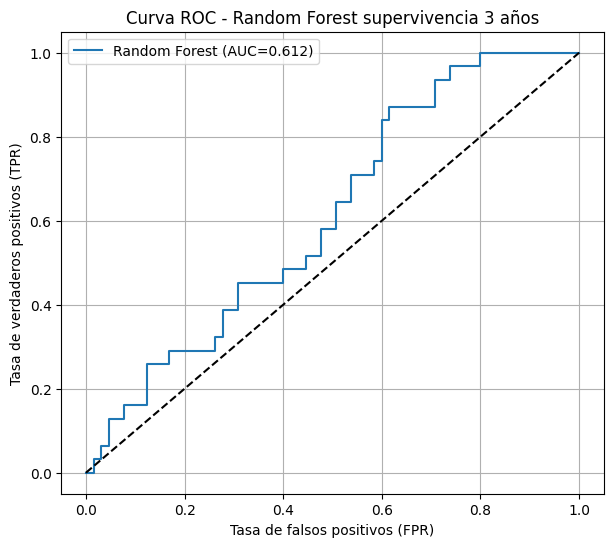

In [68]:
# Entrenamiento Random Forest
rf = RandomForestClassifier(n_estimators=300, random_state=42, min_samples_split=5, min_samples_leaf=1, max_features=0.3, max_depth=None, bootstrap=False)
rf.fit(X_train_smote, y_train_smote)

# Métricas en entrenamiento balanceado
y_pred_train_rf = rf.predict_proba(X_train)[:,1]
auc_train_rf = roc_auc_score(y_train, y_pred_train_rf)
print(f"AUC ROC entrenamiento (SMOTE): {auc_train_rf:.4f}")

# Métricas en test original
y_pred_test_rf = rf.predict_proba(X_test)[:,1]
auc_test_rf = roc_auc_score(y_test, y_pred_test_rf)
print(f"AUC ROC test: {auc_test_rf:.4f}")

# Curva ROC para test
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_test_rf)
plt.figure(figsize=(7,6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={auc_test_rf:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curva ROC - Random Forest supervivencia 3 años')
plt.legend()
plt.grid(True)
plt.show()

AUC ROC entrenamiento: 1.0000
AUC ROC test: 0.6447


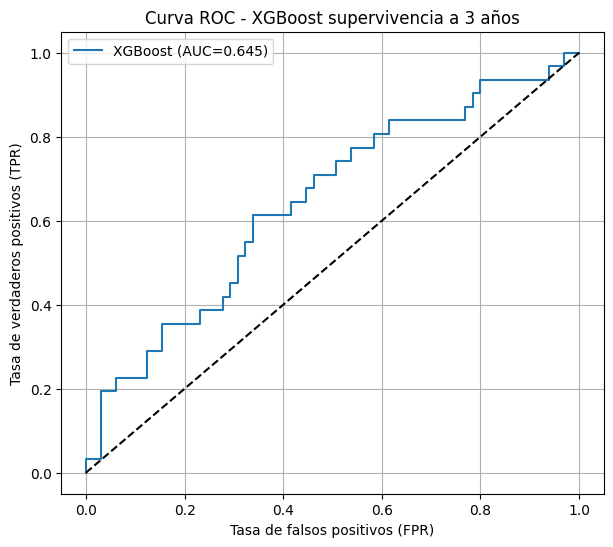

In [69]:
# Entrenamiento XGBoost
xgb_clf = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.2,
    subsample=1.0,
    colsample_bytree=0.6,
    gamma=0,
    random_state=42
)
xgb_clf.fit(X_train_smote, y_train_smote)

# Métricas en entrenamiento balanceado
y_pred_train_xgb = xgb_clf.predict_proba(X_train)[:,1]
auc_train_xgb = roc_auc_score(y_train, y_pred_train_xgb)
print(f"AUC ROC entrenamiento: {auc_train_xgb:.4f}")

# Métricas en test original
y_pred_test_xgb = xgb_clf.predict_proba(X_test)[:,1]
auc_test_xgb = roc_auc_score(y_test, y_pred_test_xgb)
print(f"AUC ROC test: {auc_test_xgb:.4f}")

# Curva ROC en test
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_test_xgb)
plt.figure(figsize=(7,6))
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC={auc_test_xgb:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curva ROC - XGBoost supervivencia a 3 años')
plt.legend()
plt.grid(True)
plt.show()

AUC ROC entrenamiento (SMOTE): 1.0000
AUC ROC test: 0.6342


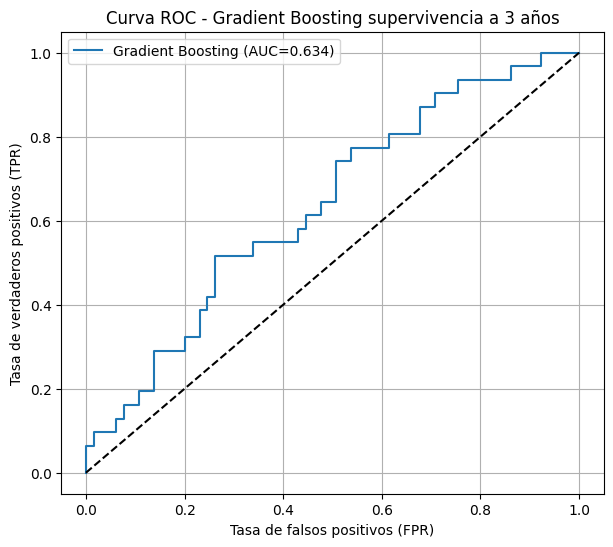

In [70]:
# Entrenamiento Gradient Boosting
gb_clf = GradientBoostingClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.2,
    subsample=1.0,
    random_state=42,
    max_features= 'sqrt',
    min_samples_leaf=2,
    min_samples_split=5
)
gb_clf.fit(X_train_smote, y_train_smote)

# Métricas en entrenamiento balanceado
y_pred_train_gb = gb_clf.predict_proba(X_train)[:,1]
auc_train_gb = roc_auc_score(y_train, y_pred_train_gb)
print(f"AUC ROC entrenamiento (SMOTE): {auc_train_gb:.4f}")

# Métricas en test original
y_pred_test_gb = gb_clf.predict_proba(X_test)[:,1]
auc_test_gb = roc_auc_score(y_test, y_pred_test_gb)
print(f"AUC ROC test: {auc_test_gb:.4f}")

# Curva ROC en test
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_pred_test_gb)
plt.figure(figsize=(7,6))
plt.plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC={auc_test_gb:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curva ROC - Gradient Boosting supervivencia a 3 años')
plt.legend()
plt.grid(True)
plt.show()


[LightGBM] [Info] Number of positive: 257, number of negative: 257
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003259 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 40393
[LightGBM] [Info] Number of data points in the train set: 514, number of used features: 319
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits w

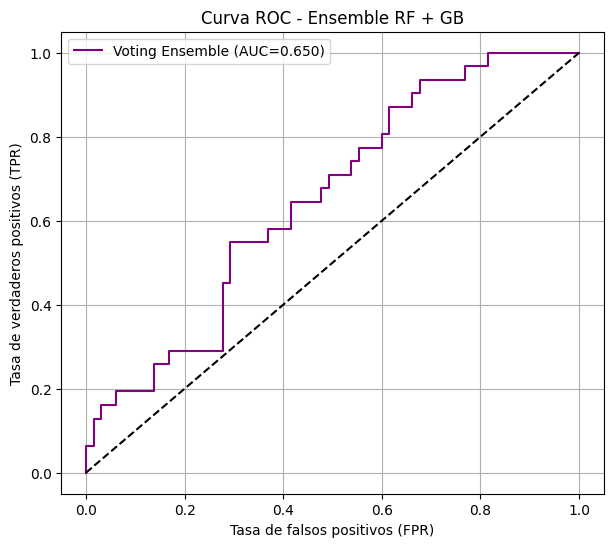

In [ ]:
from sklearn.ensemble import VotingClassifier

# Instanciar con tus modelos ya entrenados (o inicializados con los mismos parámetros)
ensemble_voting = VotingClassifier(
    estimators=[
        ('rf', rf),
        ('gb', gb_clf),
        ('xgb', xgb_clf),
        ('svm', best_model),
        ('lgbm', lgbm_clf)
    ],
    voting='soft'        # soft usa las probabilidades, hard usa clases
)

ensemble_voting.fit(X_train_smote, y_train_smote)

# Métricas en test
y_pred_test_ens = ensemble_voting.predict_proba(X_test)[:,1]
auc_test_ens = roc_auc_score(y_test, y_pred_test_ens)
print(f"AUC ROC Voting Ensemble (test): {auc_test_ens:.4f}")

fpr_ens, tpr_ens, _ = roc_curve(y_test, y_pred_test_ens)
plt.figure(figsize=(7,6))
plt.plot(fpr_ens, tpr_ens, label=f'Voting Ensemble (AUC={auc_test_ens:.3f})', color='purple')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curva ROC - Ensemble RF + GB')
plt.legend()
plt.grid(True)
plt.show()


[LightGBM] [Info] Number of positive: 257, number of negative: 257
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003776 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 40393
[LightGBM] [Info] Number of data points in the train set: 514, number of used features: 319
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits w

d:\Coding\investigacionIA\entorno\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


AUC ROC Stacking Ensemble (test): 0.6670


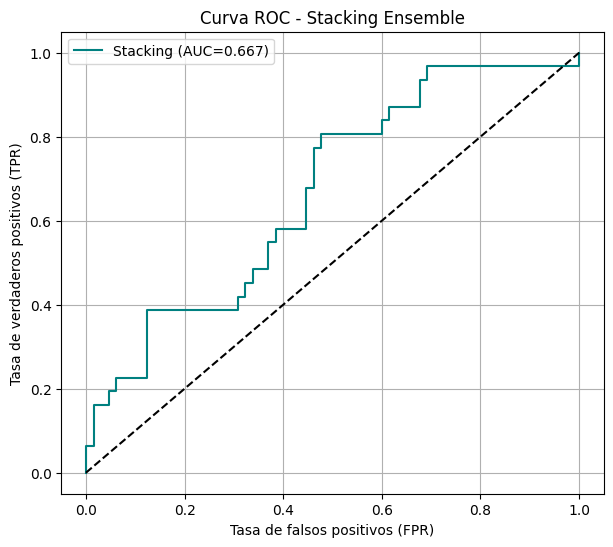

In [78]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# Stack tus modelos base y un meta-modelo (lo habitual: regresión logística)
stack_clf = StackingClassifier(
    estimators=[
        ('rf', rf),
        ('gb', gb_clf),
        ('xgb', xgb_clf),
        ('svm', best_model),
        ('lgbm', lgbm_clf)
    ],
    final_estimator=LogisticRegression(random_state=42),
    cv=5,          # validación interna de meta-modelo, puedes ajustar
    passthrough=True   # incluye X original en meta-modelo
)

stack_clf.fit(X_train_smote, y_train_smote)

# Métricas en test stacking
y_pred_test_stack = stack_clf.predict_proba(X_test)[:,1]
auc_test_stack = roc_auc_score(y_test, y_pred_test_stack)
print(f"AUC ROC Stacking Ensemble (test): {auc_test_stack:.4f}")

fpr_stack, tpr_stack, _ = roc_curve(y_test, y_pred_test_stack)
plt.figure(figsize=(7,6))
plt.plot(fpr_stack, tpr_stack, label=f'Stacking (AUC={auc_test_stack:.3f})', color='teal')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curva ROC - Stacking Ensemble')
plt.legend()
plt.grid(True)
plt.show()


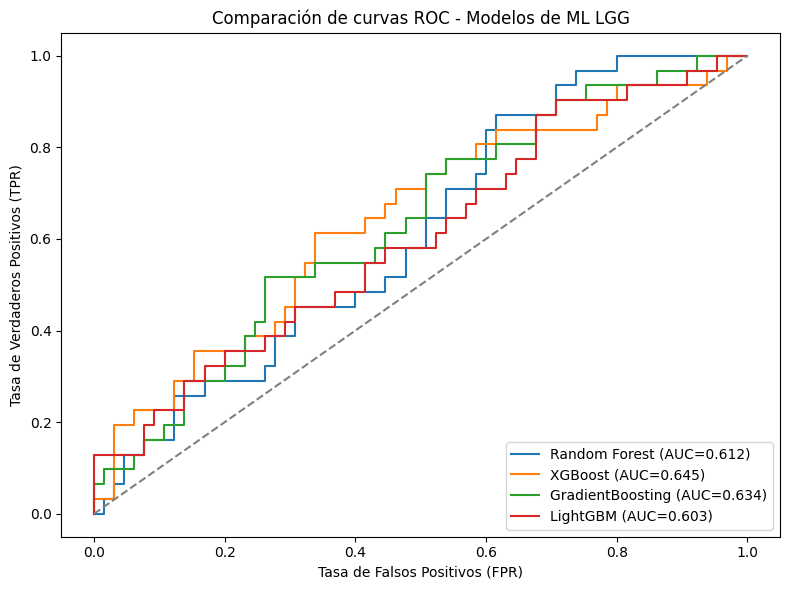

In [73]:
# Curvas ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_test_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_test_xgb)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_pred_test_gb)
fpr_lgbm, tpr_lgbm, _ = roc_curve(y_test, y_pred_test)

auc_rf = auc(fpr_rf, tpr_rf)
auc_xgb = auc(fpr_xgb, tpr_xgb)
auc_gb = auc(fpr_gb, tpr_gb)
auc_lgbm = auc(fpr_lgbm, tpr_lgbm)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={auc_rf:.3f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC={auc_xgb:.3f})')
plt.plot(fpr_gb, tpr_gb, label=f'GradientBoosting (AUC={auc_gb:.3f})')
plt.plot(fpr_lgbm, tpr_lgbm, label=f'LightGBM (AUC={auc_lgbm:.3f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Comparación de curvas ROC - Modelos de ML LGG')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()
